# Set Environment

In [25]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')

### directory
DAT_DIR = "/data/clintko/flow_EQAPOL_normal"

In [2]:
%matplotlib inline

In [3]:
def generate_sample(mean, cov, num_events):
    """Generate sample data from guassian mixed model"""
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[0] == num_events.shape[0]
    
    num_clusters = mean.shape[0]
    dat = [np.random.multivariate_normal(mean[idx], cov[idx], num_events[idx]) 
           for idx in range(num_clusters)]
    dat = np.concatenate(dat)
    return dat

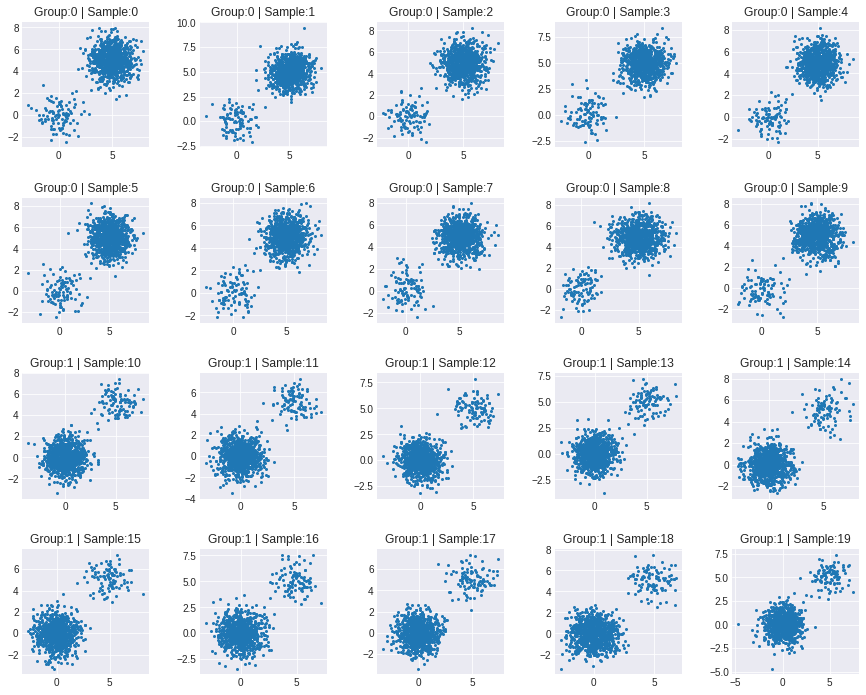

In [4]:
### Generate data
mu1 = np.array([[0, 0],[5, 5]])        ### Mean
sd1 = np.array([np.eye(2), np.eye(2)]) ### SD
nc1 = np.array([100, 900])             ### number of cells
ns1 = 10                               ### number of samples
y1  = np.array([generate_sample(mu1, sd1, nc1) for _ in range(ns1)])

mu2 = np.array([[0, 0],[5, 5]])        ### Mean
sd2 = np.array([np.eye(2), np.eye(2)]) ### SD
nc2 = np.array([900, 100])             ### number of cells
ns2 = 10                               ### number of samples
y2  = np.array([generate_sample(mu2, sd2, nc2) for _ in range(ns2)])

### combine the samples and set labels
matrix = np.concatenate([y1, y2])
label  = [0] * ns1 + [1] * ns2 

### visualization
fig, axes = plt.subplots(ncols=5, nrows=4, figsize = (3*5, 3*4))
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    ax.scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
    ax.set_title("Group:" + str(label[idx]) + " | Sample:" + str(idx))

In [5]:
### wrap up the data
print("STEP: wrap up the data")
print("+++++++++++++++++++++++++++++++++++")
%time dat_wrap = Data_Wrapper(matrix, label)
print(dat_wrap)

STEP: wrap up the data
+++++++++++++++++++++++++++++++++++
CPU times: user 0 ns, sys: 3.57 ms, total: 3.57 ms
Wall time: 994 µs
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [6]:
### Standardize the data
print("STEP: Standardize the data")
print("+++++++++++++++++++++++++++++++++++")
scaler = Transform_StandardScaler(k = 0)
scaler = scaler.fit(dat_wrap)
%time dat_scaled = scaler.transform(dat_wrap)
print(dat_scaled)

STEP: Standardize the data
+++++++++++++++++++++++++++++++++++
Transform_StandardScaler(k=0)
Total Sample: 20
Standardized based on sample: 0

***** k_th Sample: 0 *****
Mean:
[4.50466816 4.5471253 ]
SD:
[1.79683324 1.83658308]

CPU times: user 0 ns, sys: 857 µs, total: 857 µs
Wall time: 739 µs
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [7]:
### Subsetting
print("STEP: Subsetting")
print("+++++++++++++++++++++++++++++++++++")
sampler = Transform_Subsampling(n_subsample = 5, n_size = 100, random_state = 123)
%time dat_subs = sampler.fit_transform(dat_scaled)
print(dat_subs)

STEP: Subsetting
+++++++++++++++++++++++++++++++++++
CPU times: user 1.03 ms, sys: 835 µs, total: 1.87 ms
Wall time: 1.58 ms
Label: Counter({0: 50, 1: 50})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
    1: [50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]
------------------
Data Matrix: (10000, 2)
    #Samples:   100
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [8]:
### Dimensional Reduction: t-SNE
print("STEP: Dim.Reduct.")
print("+++++++++++++++++++++++++++++++++++")
tsne = Transform_TSNE(n_components = 2, n_jobs = 12, random_state = 123)
%time dat_tsne = tsne.transform(dat_subs, verbose=True)
print(dat_tsne)

STEP: Dim.Reduct.
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86

In [9]:
### Kernel Density estimation
print("STEP: Kernel Density estimation")
print("+++++++++++++++++++++++++++++++++++")
density = Transform_Density(sig2 = 5)
%time dat_img = density.transform(dat_tsne, verbose=True)
print(dat_img)

STEP: Kernel Density estimation
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample:

In [14]:
### Perform PCA and logistic regression
print("STEP: Perform PCA and logistic regression")
print("+++++++++++++++++++++++++++++++++++")
pca_logreg = Classify_PCA_LogReg(dat_img, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img)
print("===================================")
res = pca_logreg.predict(dat_img)
print(list(res.keys()))
print(res['acc'])
print(res['predicted_class'].shape)
print(res['predicted_prob'].shape)
print(res['predicted_score'].shape)
print("===================================")
print(res['predicted_class'])
print("===================================")
print(pca_logreg.model.predict(pca_logreg.X_red))
print("===================================")
print(pca_logreg)

STEP: Perform PCA and logistic regression
+++++++++++++++++++++++++++++++++++
PCA explained ratio:    0.914
PCA num components:     4
Original    data shape: (100, 32768)
PCA reduced data shape: (100, 4)
Log.Reg. Accuracy:      1.0
CPU times: user 5.01 s, sys: 2.76 s, total: 7.78 s
Wall time: 406 ms
['acc', 'predicted_class', 'predicted_prob', 'predicted_score']
1.0
(100,)
(100, 2)
(100,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Classify_PCA_LogReg(classifier=None, dat=None, pca_explained_ratio=None,
          random_state=None)


In [16]:
dat_img_train, dat_img_test = train_test_split_datawrapper(
    dat_img, 8, 5)
print(dat_img_train)
print(dat_img_test)

Label: Counter({0: 40, 1: 40})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
    1: [40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63
 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79]
------------------
Data Matrix: (8000, 2)
    #Samples:   80
    #Variables: 2
------------------
Coordinate: (8000, 2)
------------------
Image: (80, 16384, 2)

Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (2000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: (2000, 2)
------------------
Image: (20, 16384, 2)



In [21]:
### Perform PCA and logistic regression
print("STEP: Perform PCA and logistic regression: Train/Test")
print("+++++++++++++++++++++++++++++++++++")
pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img_train)
print("===================================")
res = pca_logreg.predict(dat_img_test)
print(list(res.keys()))
print(res['acc'])
print('predicted_class:', res['predicted_class'].shape)
print('predicted_prob: ', res['predicted_prob'].shape)
print('predicted_score:', res['predicted_score'].shape)
print("===================================")
print(res['predicted_class'])
print(dat_img_test.label)

STEP: Perform PCA and logistic regression: Train/Test
+++++++++++++++++++++++++++++++++++
PCA explained ratio:    0.915
PCA num components:     4
Original    data shape: (80, 32768)
PCA reduced data shape: (80, 4)
Log.Reg. Accuracy:      1.0
CPU times: user 3.67 s, sys: 3.12 s, total: 6.79 s
Wall time: 338 ms
['acc', 'predicted_class', 'predicted_prob', 'predicted_score']
1.0
predicted_class: (20,)
predicted_prob:  (20, 2)
predicted_score: (20,)
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


STEP: ROC curve
+++++++++++++++++++++++++++++++++++


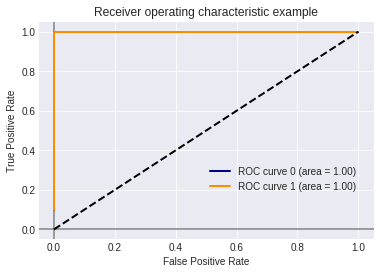

In [29]:
# Compute ROC curve and ROC area for each class
print("STEP: ROC curve")
print("+++++++++++++++++++++++++++++++++++")

### init
fpr, tpr, roc_auc = dict(), dict(), dict()
n_classes = len(dat_img.unique_label())

### get label: test data and predicted
res = pca_logreg.predict(dat_img_test)
y_prob = res['predicted_prob']
y_test = dat_img_test.label
y_test = to_categorical(y_test)

### calculate fpr and tpr
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

### Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

#######################################################

### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[0], tpr[0], color='navy',       lw=lw, label='ROC curve 0 (area = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC curve 1 (area = %0.2f)' % roc_auc[1])
#plt.plot(fpr[2], tpr[2], color='darkred',    lw=lw, label='ROC curve 2 (area = %0.2f)' % roc_auc[2])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()